# 2. Diagnostic Analytics

## Why did it happen? (Root Cause Analysis)

## Revenue Performance (Diagnostic)

# 2 - Was revenue performance by ADR or Occupancy?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

!jupyter nbconvert --to python _Exploratory_Data_Analysis.ipynb
from _Exploratory_Data_Analysis import read_table


[NbConvertApp] Converting notebook _Exploratory_Data_Analysis.ipynb to python
[NbConvertApp] Writing 2951 bytes to _Exploratory_Data_Analysis.py


# RevPAR Calculation 

RevPAR = ADR * Occupancy

ADR = room revenue / room sold

Occupancy = ( room sold / room available ) * 100

In [ ]:
yearly_room_revenue = (
    read_table("FACT_RESERVATIONS")[
        read_table("FACT_RESERVATIONS")["booking_status"] == "Checked Out"
    ]
    .merge(
        read_table("DIM_DATE"),
        how="inner",
        left_on=["check_in_date_key"],
        right_on=["date_key"],
    )
    .groupby(["year"])["room_revenue"]
    .sum()
).reset_index()


yearly_room_sold = (
    read_table("FACT_ROOM_INVENTORY")
    .merge(
        read_table("DIM_DATE"),
        how="left",
        left_on=["date_key"],
        right_on=["date_key"],
    )
    .groupby(["year"])
    .agg({"rooms_sold": "sum", "rooms_available": "sum"})
).reset_index()


yearly_kpis = yearly_room_sold.merge(yearly_room_revenue, on="year", how="left")

yearly_kpis["adr"] = yearly_kpis["room_revenue"] / yearly_kpis["rooms_sold"]

yearly_kpis["occupancy"] = (
    yearly_kpis["rooms_sold"] / yearly_kpis["rooms_available"] * 100
)
yearly_kpis["revpar"] = yearly_kpis["room_revenue"] / yearly_kpis["rooms_available"]
yearly_kpis["revpar_2"] = yearly_kpis["adr"] * yearly_kpis["occupancy"] / 100
yearly_kpis


,year,rooms_sold,rooms_available,room_revenue,adr,occupancy,revpar,revpar_2
0,2023,5269742,7685307,1.188795e+08,22.558876,68.569050,15.468407,15.468407
1,2024,5286466,7706327,1.241725e+08,23.488754,68.599036,16.113059,16.113059
2,2025,5275289,7684966,1.246662e+08,23.632108,68.644272,16.222089,16.222089


# RevPAR VIZ

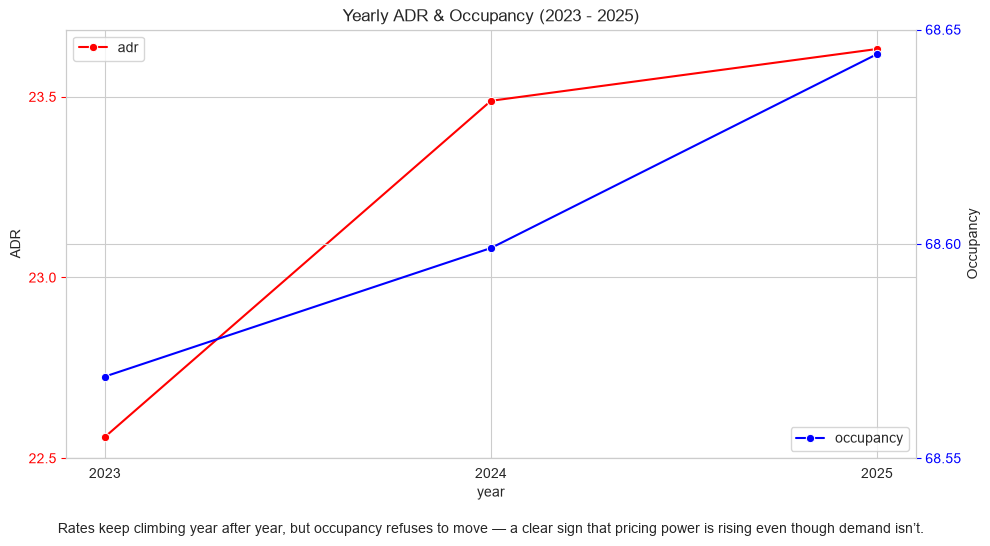

In [ ]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10,5))

sns.lineplot(x=yearly_kpis["year"],y=yearly_kpis["adr"],label="adr", color="red", marker="o",ax=ax)
ax.set_ylabel("ADR")

ax2 = ax.twinx()
sns.lineplot(x=yearly_kpis["year"],y=yearly_kpis["occupancy"],label="occupancy", color="blue", marker="o",ax=ax2)


plt.tight_layout()
plt.xticks(yearly_kpis["year"])
plt.title("Yearly ADR & Occupancy (2023 - 2025)")
plt.xlabel("Year")
plt.ylabel("Occupancy")
plt.text(
    0.5, -0.15,
    "Rates keep climbing year after year, but occupancy refuses to move — a clear sign that pricing power is rising even though demand isn’t.",
    transform=ax.transAxes,
    fontsize=10,
    ha="center",
    va="top"
)

ax.legend(loc="upper left")
ax2.legend(loc="lower right")
ax.tick_params(axis="y", colors="red")
ax2.tick_params(axis="y", colors="blue")
ax.set_yticks([22.5, 23.0, 23.5])
ax2.set_yticks([68.55, 68.60, 68.65])

plt.show()